# Generalized Additive Models (GAMs): Fundamentals

## Overview

GAMs extend linear models by replacing parametric terms (β·x) with **smooth functions** f(x) estimated from the data. This lets the model capture non-linear relationships without requiring you to specify a functional form in advance.

**Model structure:**
```
g(E[Y]) = β₀ + f₁(x₁) + f₂(x₂) + β₃·x₃ + ...
```
where g() is a link function, each f() is a smooth, and parametric terms can coexist with smooths.

| Component | Role |
|---|---|
| **Smooth term** `s(x)` | Non-linear function of a predictor, estimated from data |
| **Basis functions** | Mathematical building blocks that compose each smooth (thin plate, cubic spline, etc.) |
| **Smoothing parameter λ** | Controls wiggliness — larger λ = smoother; estimated automatically by GCV or REML |
| **Effective degrees of freedom (EDF)** | Measures smooth complexity — EDF ≈ 1 means nearly linear; higher = more wiggly |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Non-linear response of invertebrate density to temperature or pH across a gradient; species abundance as a smooth function of depth or elevation |
| **Healthcare** | Non-linear relationship between age and disease risk; how a biomarker effect changes over time non-linearly |
| **Finance** | Non-linear relationship between interest rate and default probability; smooth trend in asset prices over time |
| **Insurance** | Non-linear effect of policyholder age on claim frequency; smooth seasonal trend in claims |

---

## Assumptions Checklist

- [ ] **Correct distribution family:** Same as GLMs — response must match family (Gaussian, binomial, Poisson, etc.)
- [ ] **Additivity:** Effects of predictors are additive on the link scale — interactions require tensor product smooths (see `gam_interactions.ipynb`)
- [ ] **Sufficient basis dimension (k):** k must be large enough to represent the true smooth — check with `gam.check()` and `k.check()`
- [ ] **Adequate data for smoothing:** Smooths require sufficient data along the predictor range; sparse regions will be extrapolated unreliably
- [ ] **Independence of observations:** If data are clustered, add a random effect or use a GAMM (see mixed models folder)

> **GAMs do NOT require:**  
> Linearity between predictors and response (this is the whole point)  
> Pre-specification of the functional form

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(mgcv)         # gam() and bam() — the core GAM package in R
library(gratia)       # ggplot2-based GAM visualization and diagnostics
library(broom)        # tidy model output

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'mgcv' was built under R version 4.4.3"
Loading required package: nlme


Attaching package: 'nlme'


The fo

## Data

We simulate an ecological dataset: invertebrate density as a non-linear function of sediment pH and organic content. The true relationships are non-linear by design, making this a case where linear regression would underfit.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


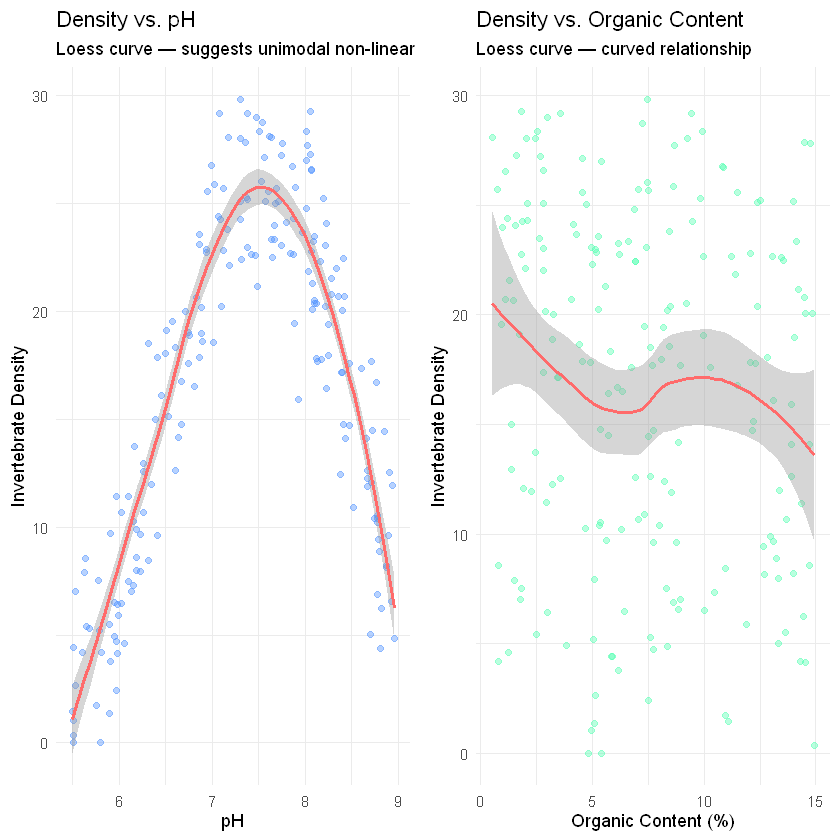

In [2]:
# ── Simulate non-linear ecological data ──────────────────────────────────────
n <- 200
eco_data <- tibble(
  pH      = runif(n, 5.5, 9.0),
  organic = runif(n, 0.5, 15),
  # True relationship: unimodal peak around pH 7.5, declining with organic
  density = 30 * exp(-((pH - 7.5)^2) / 2) -
            0.8 * organic +
            0.04 * organic^2 +
            rnorm(n, 0, 3)
) %>%
  mutate(density = pmax(density, 0))  # counts can't be negative

# ── Exploratory plots ─────────────────────────────────────────────────────────
p1 <- ggplot(eco_data, aes(x = pH, y = density)) +
  geom_point(alpha = 0.4, color = "#4a8fff") +
  geom_smooth(method = "loess", se = TRUE, color = "#ff6b6b") +
  labs(title = "Density vs. pH",
       subtitle = "Loess curve — suggests unimodal non-linear relationship",
       x = "pH", y = "Invertebrate Density") +
  theme_minimal()

p2 <- ggplot(eco_data, aes(x = organic, y = density)) +
  geom_point(alpha = 0.4, color = "#4fffb0") +
  geom_smooth(method = "loess", se = TRUE, color = "#ff6b6b") +
  labs(title = "Density vs. Organic Content",
       subtitle = "Loess curve — curved relationship",
       x = "Organic Content (%)", y = "Invertebrate Density") +
  theme_minimal()

gridExtra::grid.arrange(p1, p2, ncol = 2)
# Loess curves suggest non-linearity — motivates GAM over linear regression

---

## Fitting a Basic GAM

The `s()` wrapper specifies a smooth term. `mgcv` automatically selects the smoothing parameter using REML by default.

In [3]:
# ── Fit GAM with two smooth terms ─────────────────────────────────────────────
gam1 <- mgcv::gam(
  density ~ s(pH) + s(organic),
  data   = eco_data,
  method = "REML"    # REML is strongly preferred over GCV for smoothing parameter selection
)
summary(gam1)

# ── Reading the summary ───────────────────────────────────────────────────────
# Parametric coefficients: intercept and any linear terms
# Approximate significance of smooth terms:
#   edf (effective degrees of freedom): 1 = linear; higher = more complex curve
#   F statistic and p-value: tests whether smooth is significantly different from zero
# R-sq (adj): adjusted R² — proportion of variance explained
# Deviance explained: analogous to R² for non-Gaussian families
# GCV / REML score: used for smoothing parameter selection (lower = better)


Family: gaussian 
Link function: identity 

Formula:
density ~ s(pH) + s(organic)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  16.7544     0.1929   86.85   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf Ref.df      F  p-value    
s(pH)      6.763  7.862 188.32  < 2e-16 ***
s(organic) 2.045  2.527  10.73 1.59e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.885   Deviance explained =   89%
-REML = 495.02  Scale est. = 7.4436    n = 200

---

## Basis Functions and k

Each smooth is built from a set of basis functions. The `k` argument sets the **maximum** number of basis functions (the dimension of the basis). The actual wiggliness is controlled by the smoothing parameter λ, so k mainly sets an upper bound.

| Basis type | `bs=` | Use case |
|---|---|---|
| Thin plate regression spline (default) | `"tp"` | General purpose; data-driven; good default |
| Cubic regression spline | `"cr"` | Smooth, well-behaved; good for most cases |
| Cyclic cubic spline | `"cc"` | Periodic data (seasons, time of day) |
| P-spline | `"ps"` | Evenly spaced knots; slightly different penalty |
| Random effect | `"re"` | Parametric random intercept — equivalent to `lme4` |
| Soap film | `"so"` | Spatial smoothing within irregular boundaries |

In [4]:
# ── Effect of k on smoothness ─────────────────────────────────────────────────
gam_k5  <- mgcv::gam(density ~ s(pH, k = 5),  data = eco_data, method = "REML")
gam_k10 <- mgcv::gam(density ~ s(pH, k = 10), data = eco_data, method = "REML")
gam_k20 <- mgcv::gam(density ~ s(pH, k = 20), data = eco_data, method = "REML")

# Compare EDF across k settings — EDF much less than k means k was large enough
cat(sprintf("k=5:  EDF = %.2f\n", sum(summary(gam_k5)$edf)))
cat(sprintf("k=10: EDF = %.2f\n", sum(summary(gam_k10)$edf)))
cat(sprintf("k=20: EDF = %.2f\n", sum(summary(gam_k20)$edf)))
# If EDF is close to k-1, k may be too small — increase k and recheck

# ── Check whether k is adequate ──────────────────────────────────────────────
mgcv::k.check(gam1)
# k-index < 1 and p < 0.05: k is likely too small, increase it
# k-index >= 1: k is adequate

# ── Different basis types ─────────────────────────────────────────────────────
gam_cr  <- mgcv::gam(density ~ s(pH, bs = "cr"),  data = eco_data, method = "REML")
gam_tp  <- mgcv::gam(density ~ s(pH, bs = "tp"),  data = eco_data, method = "REML")  # default
AIC(gam_cr, gam_tp)  # usually very similar

k=5:  EDF = 3.93
k=10: EDF = 6.54
k=20: EDF = 7.19


,k',edf,k-index,p-value
s(pH),9,6.762901,1.073167,0.8625
s(organic),9,2.044701,1.007153,0.5025


,df,AIC
,<dbl>,<dbl>
gam_cr,8.714789,1004.131
gam_tp,8.736897,1004.391


---

## Mixing Smooth and Parametric Terms

GAMs can include both smooth terms and standard linear (parametric) terms in the same model. This is useful when some predictors are genuinely linear or when you want to include a categorical predictor.

In [5]:
# ── Add a categorical predictor ───────────────────────────────────────────────
eco_data$habitat <- sample(c("intertidal", "subtidal"), n, replace = TRUE)

# Smooth for pH + linear term for organic + categorical habitat
gam_mixed <- mgcv::gam(
  density ~ s(pH) + organic + habitat,
  data   = eco_data,
  method = "REML"
)
summary(gam_mixed)
# habitat appears in the parametric coefficients section
# organic appears as a linear parametric term
# s(pH) appears in the smooth terms section

# ── Force a smooth to be linear ───────────────────────────────────────────────
# s(x, k=1) or just include x directly — let the model decide
gam_test_lin <- mgcv::gam(
  density ~ s(pH) + s(organic, k = 3),
  data = eco_data, method = "REML"
)
# If EDF for organic ≈ 1, the smooth is effectively linear
# Can then simplify to a parametric term


Family: gaussian 
Link function: identity 

Formula:
density ~ s(pH) + organic + habitat

Parametric coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     18.53966    0.45335  40.895  < 2e-16 ***
organic         -0.22583    0.04668  -4.838 2.71e-06 ***
habitatsubtidal -0.24148    0.39649  -0.609    0.543    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
       edf Ref.df     F p-value    
s(pH) 6.71  7.819 186.1  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.882   Deviance explained = 88.7%
-REML = 497.01  Scale est. = 7.5951    n = 200

---

## Predictions from GAMs

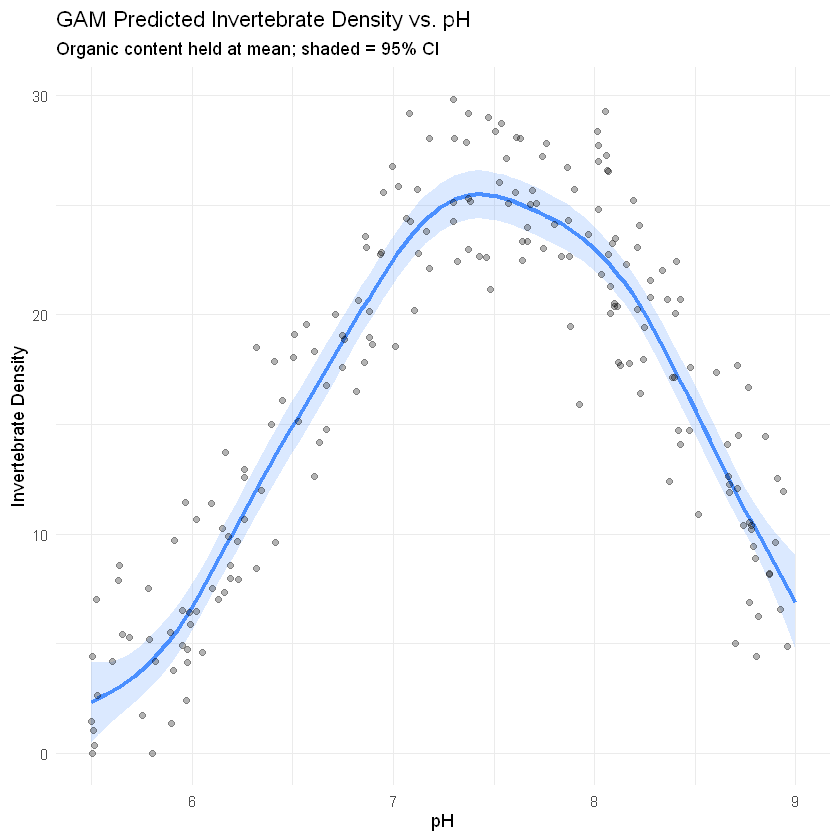

In [6]:
# ── Predict over a grid ───────────────────────────────────────────────────────
pred_grid <- data.frame(
  pH      = seq(5.5, 9.0, length.out = 100),
  organic = mean(eco_data$organic)
)

# type = "response" returns predictions on the response scale
# type = "link" returns predictions on the link scale
# se.fit = TRUE adds standard errors for confidence bands
preds <- predict(gam1, newdata = pred_grid, type = "response", se.fit = TRUE)
pred_grid$fit  <- preds$fit
pred_grid$se   <- preds$se.fit
pred_grid$lower <- pred_grid$fit - 1.96 * pred_grid$se
pred_grid$upper <- pred_grid$fit + 1.96 * pred_grid$se

ggplot() +
  geom_ribbon(data = pred_grid,
              aes(x = pH, ymin = lower, ymax = upper),
              alpha = 0.2, fill = "#4a8fff") +
  geom_line(data = pred_grid,
            aes(x = pH, y = fit),
            color = "#4a8fff", linewidth = 1.2) +
  geom_point(data = eco_data,
             aes(x = pH, y = density),
             alpha = 0.3, size = 1.5) +
  labs(title = "GAM Predicted Invertebrate Density vs. pH",
       subtitle = "Organic content held at mean; shaded = 95% CI",
       x = "pH", y = "Invertebrate Density") +
  theme_minimal()

---

## Visualizing Smooths with `gratia`

`gratia` provides `ggplot2`-based smooth visualizations that are far cleaner than `mgcv`'s base R plots.

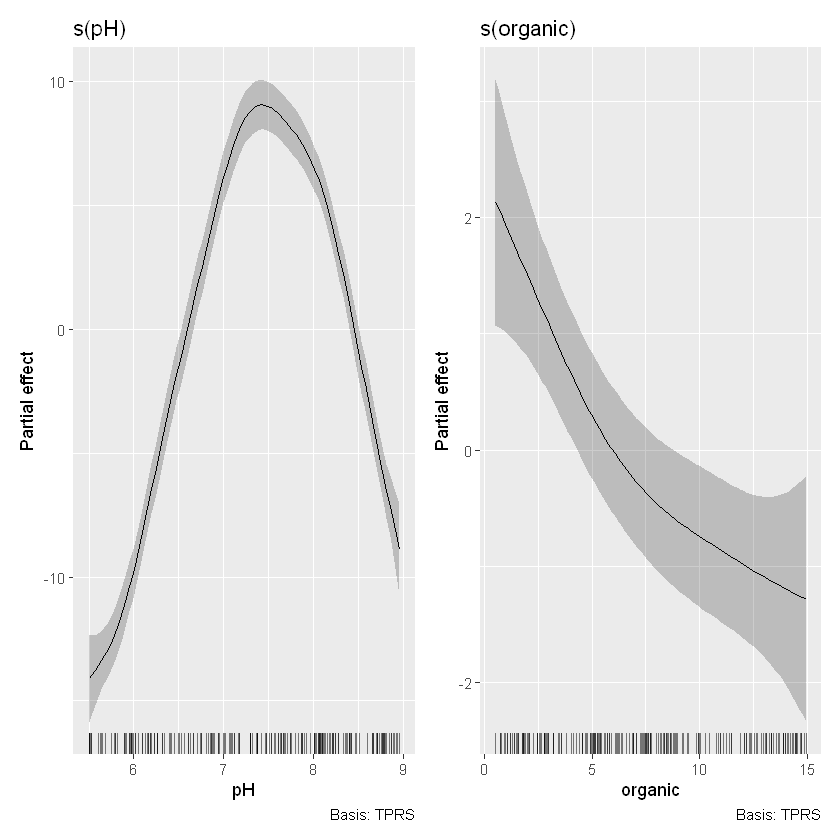

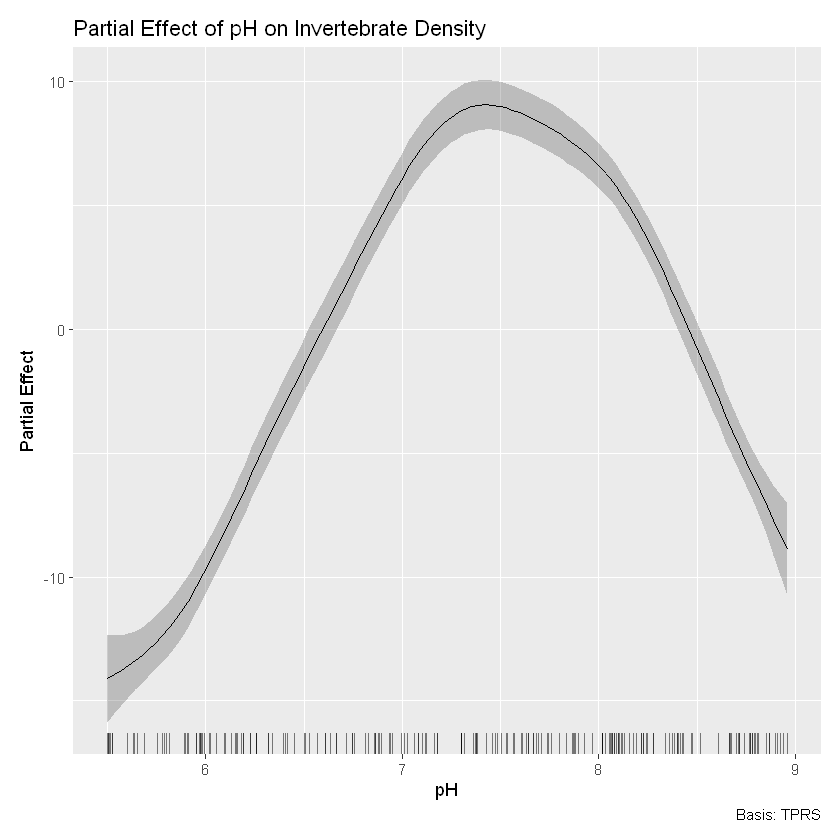

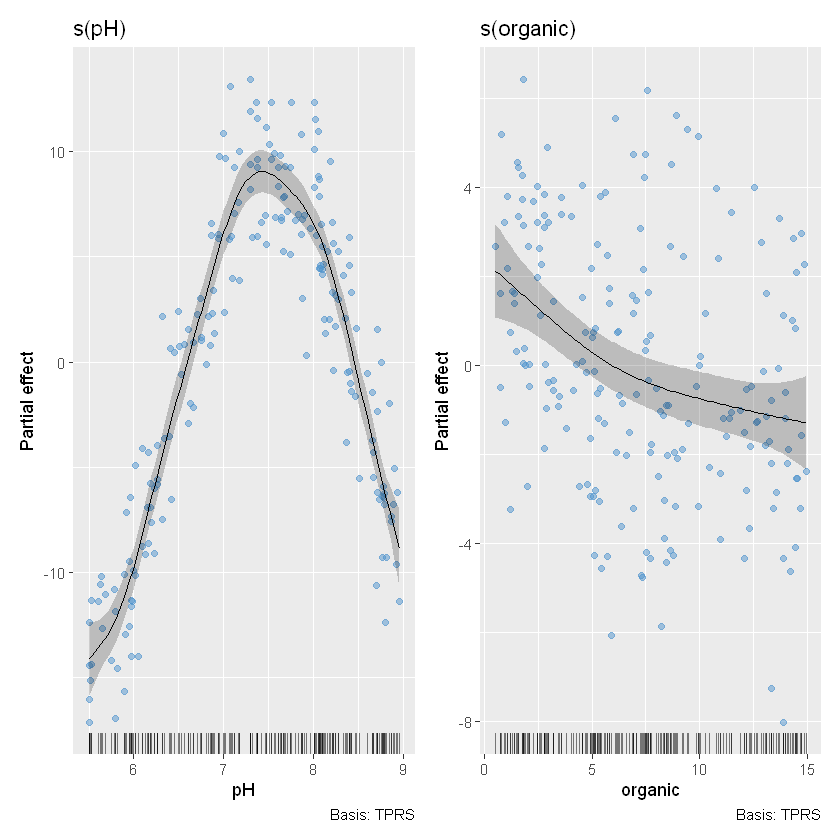

In [7]:
# ── Draw all smooths ──────────────────────────────────────────────────────────
gratia::draw(gam1)
# One panel per smooth; shows the partial effect of each predictor
# Shaded band = 95% confidence interval
# Rug marks at bottom = data density along predictor
# Note: partial effects are centered at zero by default

# ── Draw individual smooth ────────────────────────────────────────────────────
gratia::draw(gam1, select = "s(pH)") +
  labs(title = "Partial Effect of pH on Invertebrate Density",
       x = "pH", y = "Partial Effect")

# ── Add partial residuals ─────────────────────────────────────────────────────
gratia::draw(gam1, residuals = TRUE)
# Residuals overlaid on smooth — should be randomly scattered around the curve

---

## Reporting Results

In [8]:
# ── Model summary components ──────────────────────────────────────────────────
s <- summary(gam1)

cat("Parametric terms:\n")
print(round(s$p.table, 4))

cat("\nSmooth terms:\n")
print(round(s$s.table, 4))

cat(sprintf("\nR-sq (adj) = %.3f | Deviance explained = %.1f%%\n",
            s$r.sq, s$dev.expl * 100))

# Standard reporting format:
# "We fitted a GAM with smooth terms for pH and organic content (mgcv;
#  Wood 2017), with smoothing parameters selected by REML. pH had a
#  significant non-linear effect on invertebrate density
#  (s(pH): F = X.XX, p < .001, EDF = X.XX), consistent with a unimodal
#  response peaking near pH 7.5. Organic content also had a significant
#  effect (s(organic): F = X.XX, p = .XXX, EDF = X.XX).
#  The model explained XX% of deviance (adj. R² = .XX)."
#
# Always cite: Wood SN (2017) Generalized Additive Models: An Introduction
# with R (2nd ed). Chapman and Hall/CRC.

Parametric terms:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  16.7544     0.1929 86.8465        0

Smooth terms:
              edf Ref.df        F p-value
s(pH)      6.7629 7.8624 188.3203       0
s(organic) 2.0447 2.5273  10.7325       0

R-sq (adj) = 0.885 | Deviance explained = 89.0%


---

## Common Pitfalls

**1. Using GCV instead of REML for smoothing parameter selection**  
GCV can produce overly wiggly smooths in some cases. Always use `method = "REML"` unless you have a specific reason not to.

**2. Not checking whether k is large enough**  
If k is too small, the smooth will be artificially constrained. Always run `gam.check()` or `k.check()` and increase k if the k-index is less than 1 with a significant p-value.

**3. Interpreting EDF as degrees of freedom in the classical sense**  
EDF quantifies smooth complexity, not the number of parameters in the traditional sense. An EDF of 1 means the smooth is effectively linear; higher values indicate more complex curves.

**4. Extrapolating smooths beyond the data range**  
GAM smooths are only reliable within the range of the observed predictor values. Predictions outside this range can behave erratically.

**5. Not checking for concurvity**  
Concurvity is the GAM analog of multicollinearity — when predictors are related, smooth estimates become unstable. Check with `concurvity()` after fitting (see `gam_diagnostics.ipynb`).

**6. Using GAMs when a simpler model fits equally well**  
If all smooth EDFs are approximately 1, a linear model may be sufficient. Always compare GAM to GLM with AIC (see `gam_vs_glm.ipynb`).

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*